# Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the distribution of variables and identify patterns associated with customer churn. 

The goal is to explore how customer behavior, service usage, and account characteristics relate to churn outcomes in the telecom dataset.

## Importing Required Libraries

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Loading the Processed Dataset

The cleaned dataset produced during the preprocessing stage is loaded for exploratory analysis.

In [3]:
df = pd.read_csv("cleaned_churn_dataset.csv")
df.head()

,state,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,customer_service_calls,churn
0,KS,128,415,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,OH,107,415,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,NJ,137,415,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,OH,84,408,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,OK,75,415,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


## Churn Distribution

Understanding the proportion of churned and retained customers provides an initial overview of the dataset and helps identify potential class imbalance.

In [4]:
df["churn"].value_counts()

churn
0    2850
1     483
Name: count, dtype: int64

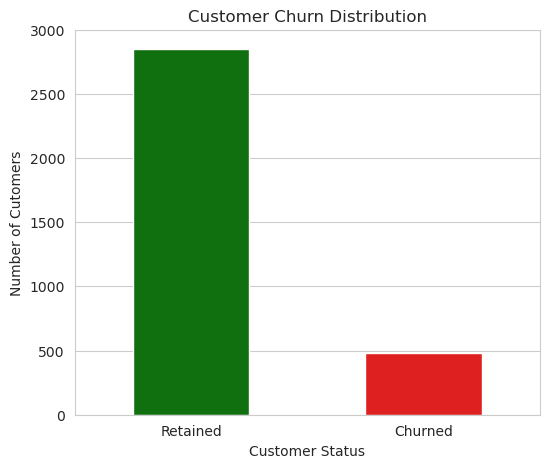

In [5]:
churn_label = df["churn"].map({0:"Retained",1:"Churned"})
plt.figure(figsize = (6,5))
sns.set_style("whitegrid")
sns.countplot(
    x = churn_label, 
    hue = churn_label, 
    palette = ["green","red"], 
    width = 0.5, 
    legend = False)
plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylim(0,3000)
plt.ylabel("Number of Cutomers")
plt.show()

## Account Tenure and Churn

Customer tenure may influence churn behavior. 
New customers may be more likely to leave compared to long-term subscribers.

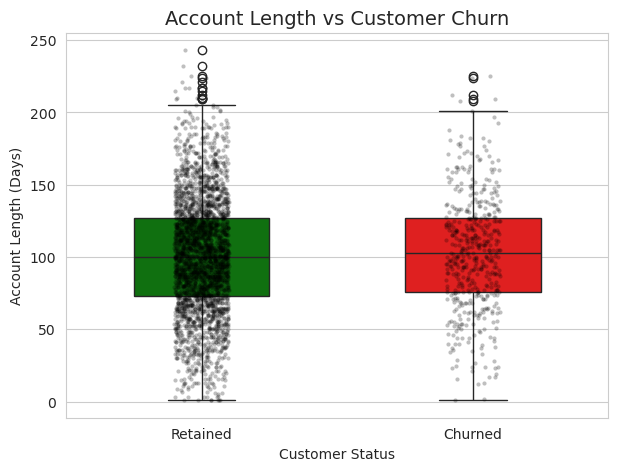

In [6]:
plt.figure(figsize=(7,5))
sns.set_style("whitegrid")

sns.boxplot(
    x="churn",
    y="account_length",
    data=df,
    hue = "churn",
    palette=["green", "red"],   
    width=0.5,
    legend = False
)

sns.stripplot(
    x="churn",
    y="account_length",
    data=df,
    color="black",
    alpha=0.25,
    size=3,
    jitter=True
)

plt.title("Account Length vs Customer Churn", fontsize=14)
plt.xlabel("Customer Status")
plt.ylabel("Account Length (Days)")
plt.xticks([0,1], ["Retained", "Churned"])

plt.show()

Account tenure distributions are similar for retained and churned users, but retained users show higher density within the interquartile range, while both groups have extreme long-tenure outliers.

## Customer Service Interactions and Churn

Frequent customer support interactions may indicate dissatisfaction with the service. 
This section examines whether customers who contact support more frequently have a higher churn probability.

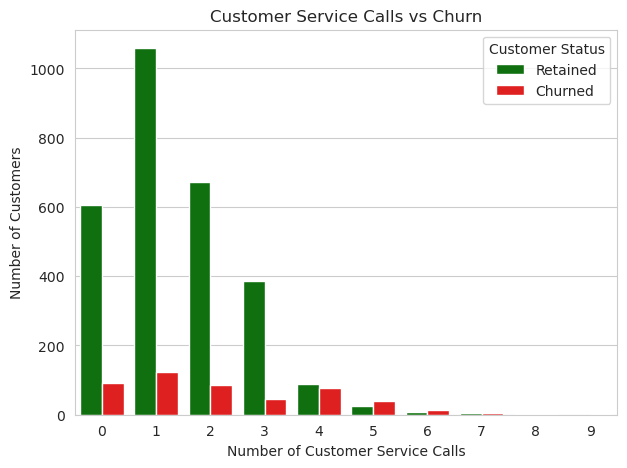

In [7]:
plt.figure(figsize=(7,5))
sns.set_style("whitegrid")

sns.countplot(
    x="customer_service_calls",
    hue="churn",
    data=df,
    palette=["green","red"]
)

plt.title("Customer Service Calls vs Churn")
plt.xlabel("Number of Customer Service Calls")
plt.ylabel("Number of Customers")

plt.legend(title="Customer Status", labels=["Retained","Churned"])

plt.show()

Customers with 0–2 service calls are mostly retained, while higher call counts (3+) correlate with increased churn, highlighting unresolved issues as a churn signal.

## International Plan Subscription

Customers with international calling plans may exhibit different churn patterns due to pricing or usage behavior.

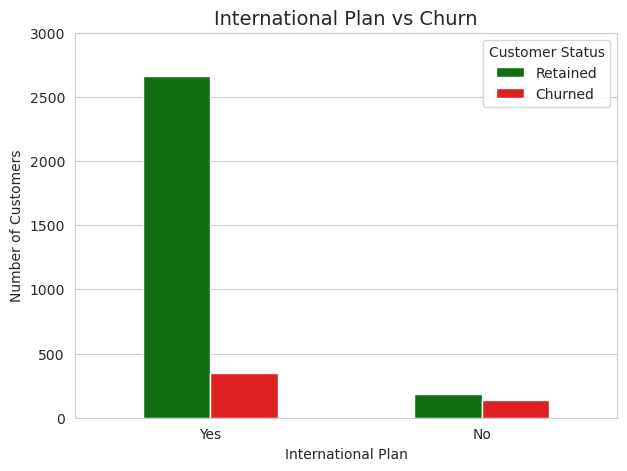

In [8]:
plt.figure(figsize=(7,5))
sns.set_style("whitegrid")
sns.countplot(x = "international_plan",
              data = df, 
              hue = "churn", 
              palette = ["green", "red"], 
              width = 0.5)
plt.title("International Plan vs Churn", fontsize = 14)
plt.xlabel("International Plan")
plt.ylabel("Number of Customers")
plt.ylim(0,3000)
plt.xticks([0,1], ["Yes","No"])
plt.legend(title = "Customer Status", labels = ["Retained","Churned"])
plt.show()

Customers with an international plan are mostly retained, though a small portion churns. Among those without a plan, retention and churn are more balanced, suggesting the plan may contribute to higher retention.

## Voice Mail Plan and Customer Retention

Additional services such as voicemail plans may contribute to customer retention.

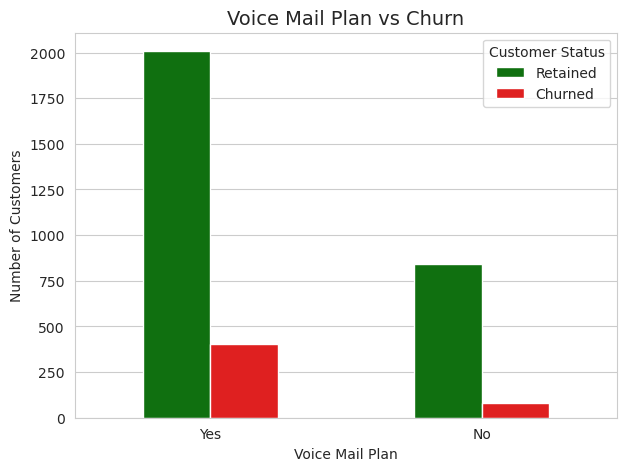

In [9]:
plt.figure(figsize=(7,5))
sns.countplot(x='voice_mail_plan',
              data = df, 
              width = 0.5, 
              hue = "churn", 
              palette = ["green","red"])
plt.title("Voice Mail Plan vs Churn", fontsize = 14)
plt.ylabel("Number of Customers")
plt.xlabel("Voice Mail Plan")
plt.legend(title = "Customer Status", labels = ["Retained","Churned"])
plt.xticks([0,1],["Yes","No"])
plt.show()

Customers with a voicemail plan are mostly retained, though some churn. Customers without a plan also show substantial retention, but churn is proportionally lower, indicating the plan boosts retention but retention exists even without it.

## Call Usage Behavior

Customer call usage patterns during different time periods (day, evening, night) are examined to determine whether heavy usage is associated with churn.

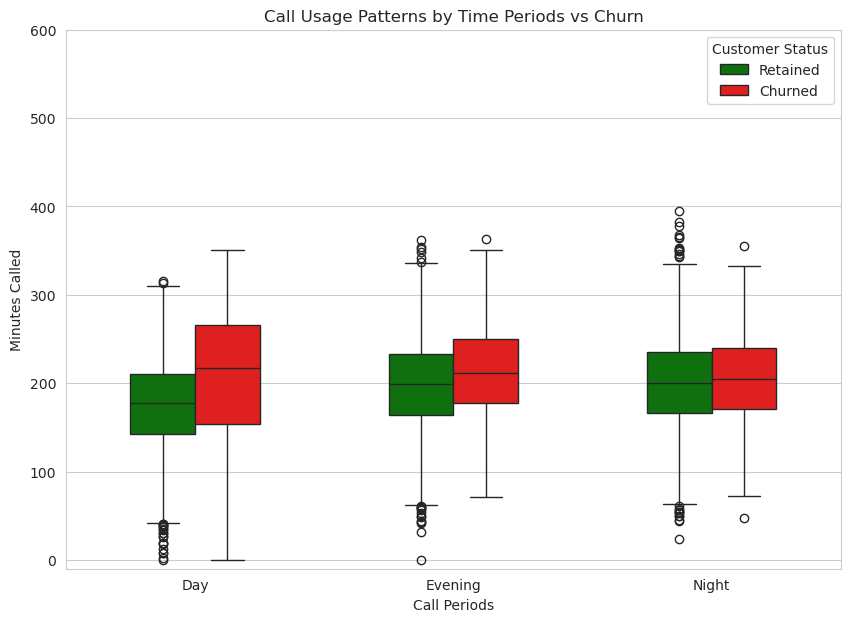

In [10]:
plt.figure(figsize=(10,7))
sns.set_style("whitegrid")

temp = df.melt(
    id_vars="churn",
    value_vars=["total_day_minutes","total_eve_minutes","total_night_minutes"],
    var_name="Time Periods",
    value_name="Total Calls"
)

temp["Customer Status"] = temp["churn"].map({0: "Retained", 1: "Churned"})

sns.boxplot(
    x="Time Periods",
    y="Total Calls",
    hue="Customer Status",
    data=temp,
    palette=["green","red"],
    width = 0.5,
)

plt.title("Call Usage Patterns by Time Periods vs Churn")
plt.xlabel("Call Periods")
plt.ylabel("Minutes Called")
plt.ylim(-10,600)
plt.legend(title="Customer Status")
plt.xticks(["total_day_minutes","total_eve_minutes","total_night_minutes"],["Day","Evening","Night"])
plt.show()

Churned customers show higher daytime call minutes, making it the strongest churn indicator, while evening and night usage are similar across groups. Extreme high-usage outliers exist in all periods, suggesting a small distinct segment independent of churn.

## Feature Correlation Analysis

Correlation analysis helps identify relationships between numerical features and the churn variable.

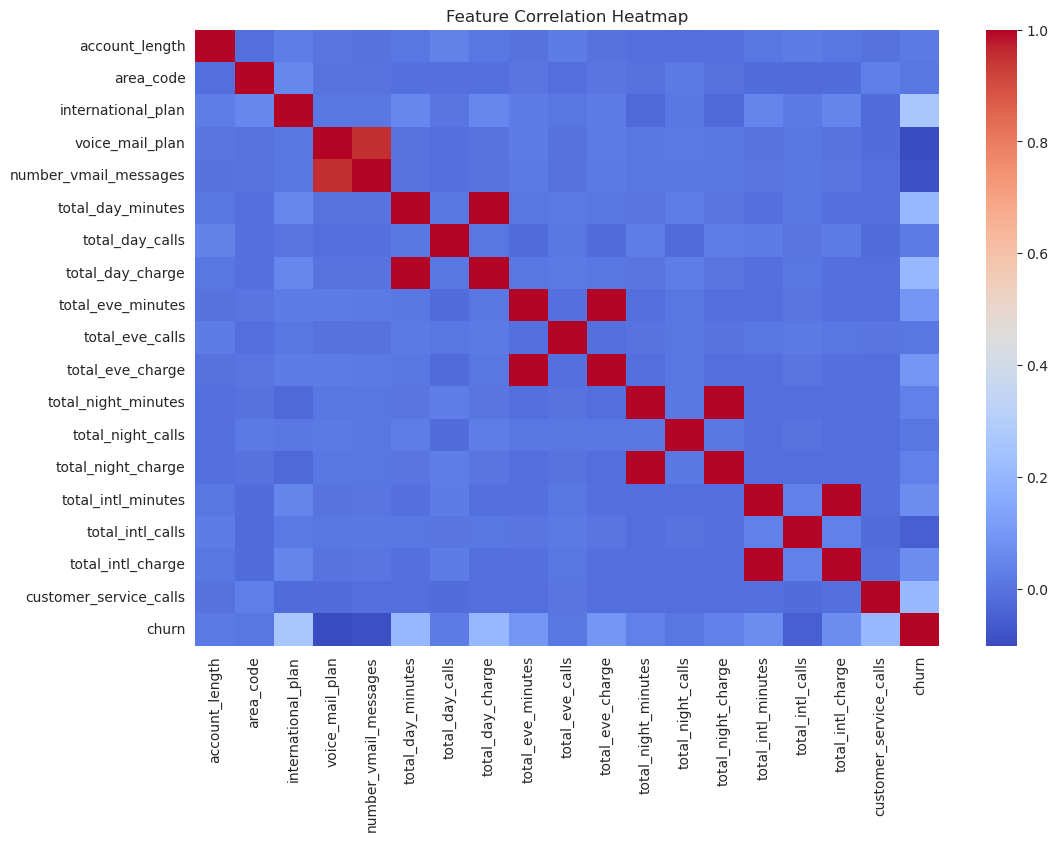

In [16]:
numeric_df = df.select_dtypes(include = ['int64','float64'])
plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("corr.png")
plt.show()

Usage minutes and their corresponding charges are perfectly correlated, so charge columns can be removed to avoid redundancy. Churn shows little linear correlation with other features, suggesting non-linear models like tree-based methods are better suited to capture its drivers.

## Key Insights from Exploratory Data Analysis

1. **Class Imbalance**  
   - The majority of customers are retained (2850), while a smaller portion churned (483), indicating a class imbalance to consider during modeling.

2. **Account Tenure**  
   - Retained customers show slightly higher density within the interquartile range.  
   - Extremely long-tenure outliers exist in both groups.  
   - Account length alone is not a strong linear predictor but provides context.

3. **Customer Service Calls**  
   - Customers with 0–2 service calls are mostly retained.  
   - 3 or more service calls correlate with higher churn, highlighting unresolved issues as a strong churn signal.

4. **International Plan**  
   - Customers with an international plan are mostly retained, while those without the plan show a more balanced retention/churn distribution.  
   - Suggests the plan contributes to higher retention, but some churn still occurs.

5. **Voice Mail Plan**  
   - Customers with a voicemail plan are mostly retained, though retention also exists among non-plan users.  
   - Indicates the plan can boost retention, but is not strictly necessary.

6. **Call Usage Patterns**  
   - Daytime call minutes are higher for churned customers, making it the **strongest usage-based churn indicator**.  
   - Evening and night usage are similar across churn groups.  
   - Extreme high-usage outliers exist in all periods, representing a small distinct customer segment.

7. **Charges vs Usage**  
   - Usage minutes and their corresponding charges are perfectly correlated.  
   - Charge columns can be removed to avoid redundancy.

8. **Correlation with Churn**  
   - Linear correlation between features and churn is low.  
   - Suggests non-linear models like tree-based algorithms will better capture the drivers of churn.

**Overall Insight:**  
Frequent service calls and high daytime usage are the strongest indicators of churn. Additional services such as international or voicemail plans generally improve retention. Modeling efforts should focus on non-linear relationships to effectively predict churn.